# 📝 Instrucciones:
# Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre medical_insurance_cost.csv. Puedes cargarlo en el código directamente desde el siguente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv
O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

age. Edad del beneficiario principal (numérico)
sex. Género del beneficiario principal (categórico)
bmi. índice de masa corporal (numérico)
children. Número de niños/dependientes cubiertos por un seguro médico (numérico)
smoker. ¿Es fumador? (categórico)
region. Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)
charges. Prima del seguro médico (numérico)
# Paso 2: Realiza un EDA completo
Este segundo paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.

# Paso 3: Construye un modelo de regresión lineal
No es necesario que optimices los hiperparámetros. Comienza utilizando una definición por defecto y mejórala en el paso siguiente.

# Paso 4: Optimiza el modelo anterior
Después de entrenar el modelo, si los resultados no son satisfactorios, optimízalo si fuera posible.

In [1]:
#importamos librerias

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 
import scipy.stats as stats
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------------------------------------------------

# Paso 1  cargamos los datos 

In [2]:
df = pd.read_csv("../data/raw/medical_insurance_cost.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.shape

(1338, 7)

In [7]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [8]:
print("PORCENTAJE DE VALORES NULOS DEL dataset\n")
#Obtenemos que columnas tienen valores nulos y porcentage respectivamente
info_nulls = pd.DataFrame({
    '% Nullidad': df.isna().sum() / len(df) * 100
}).sort_values(by='% Nullidad', ascending = False)
info_nulls

PORCENTAJE DE VALORES NULOS DEL dataset



,% Nullidad
age,0.0
sex,0.0
bmi,0.0
children,0.0
smoker,0.0
region,0.0
charges,0.0


Este data set incluye tanto variables numéricas como categóricas. Entre las numéricas destacan la edad (age), el índice de masa corporal (bmi), el número de dependientes (children) y el coste del seguro (charges). Por otro lado, se identificaron variables categóricas como el género (sex), el hábito de fumar (smoker) y la región de residencia (region).

Este análisis preliminar permitió confirmar que la información está correctamente estructurada, que las columnas poseen nombres claros y que, en las primeras observaciones, no se aprecian valores atípicos ni valores nulos 

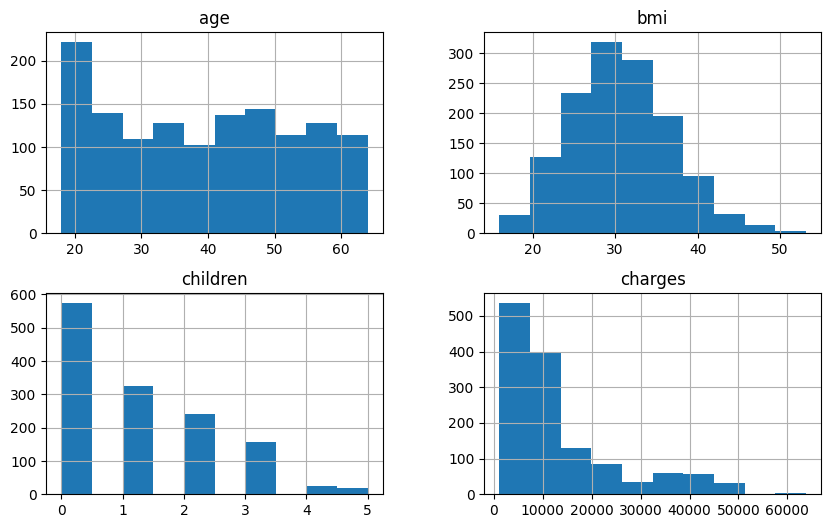

In [9]:
df.hist(figsize=(10,6))
plt.show()

Podemos observar que la variable bmi sigue una distribucion normal y que la variable edad sigue una distribucion uniforme. La variable children podemos observar que la mayoria de las personas no tienen dependientes a su cargo y con respecto a la variable objetivo, se observa que las cantidades estan muy sesgadas a la derecha 

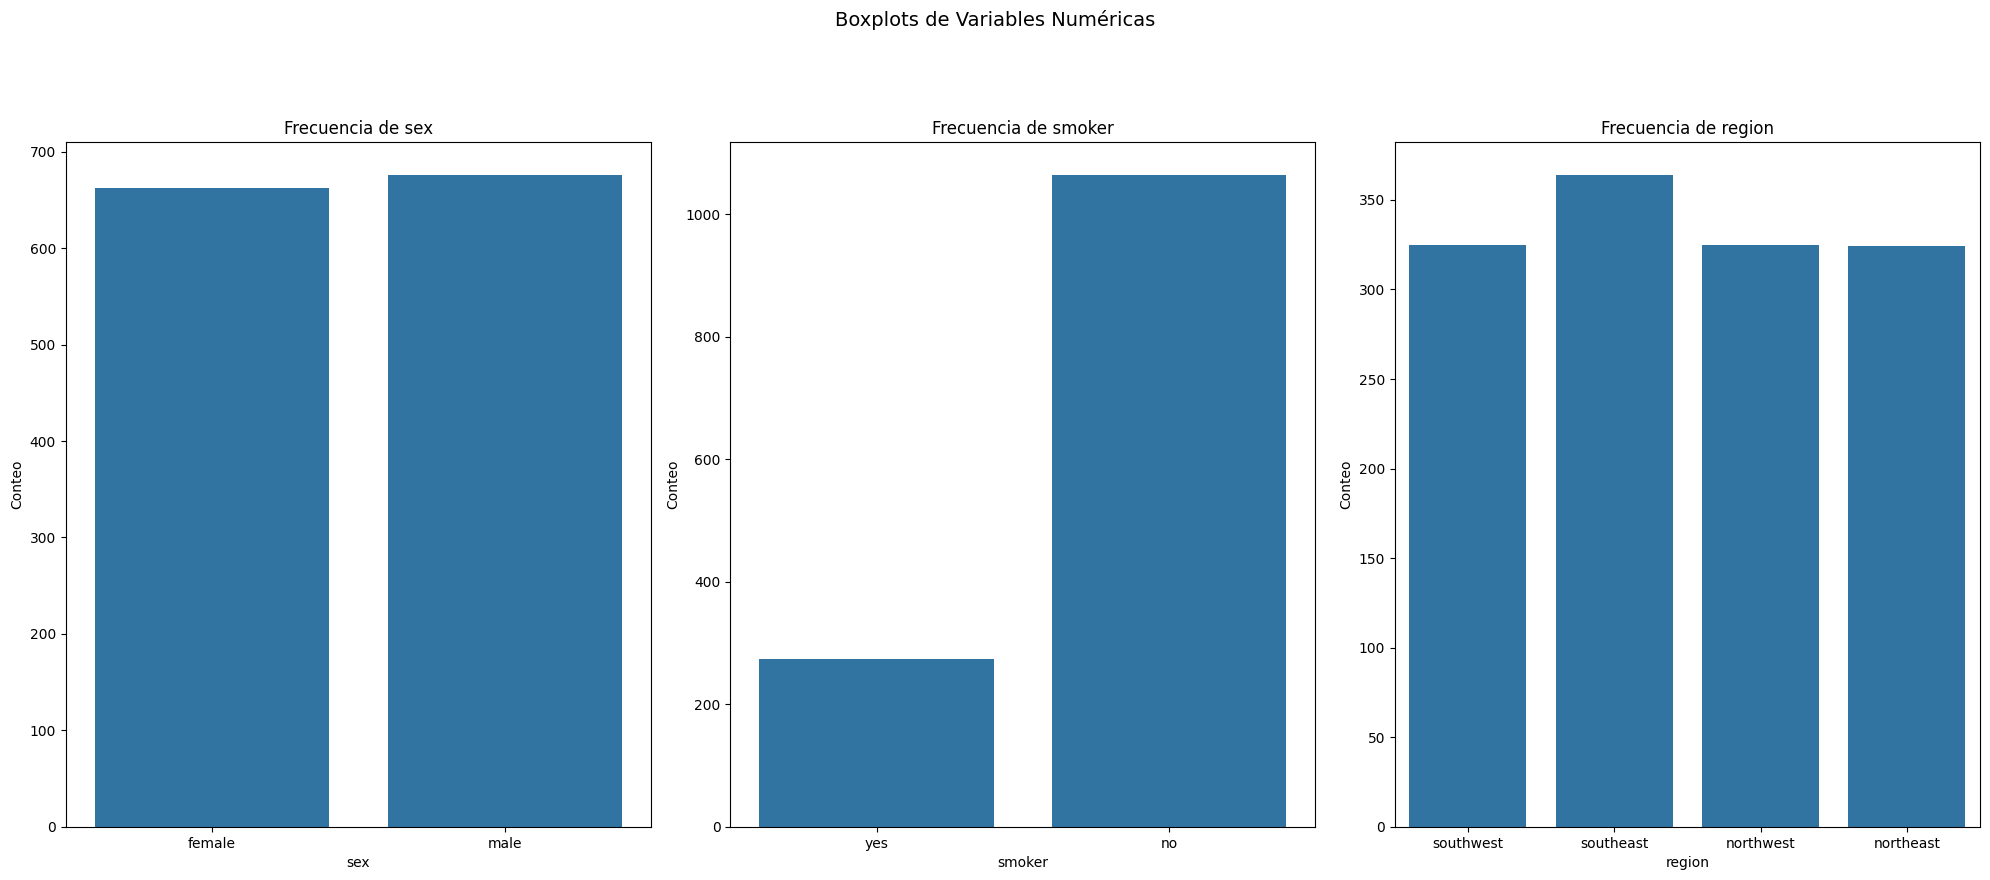

In [10]:
cat_cols = ["sex", "smoker", "region"]

fig, axes = plt.subplots(4, 3, figsize=(20, 30))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Frecuencia de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Conteo")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots de Variables Numéricas', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Se muestra un gran equilibro entre la variable sexo y region  con diferencias muy minimas, a destacar de esta grafica es que los asegurados no son fumadores.

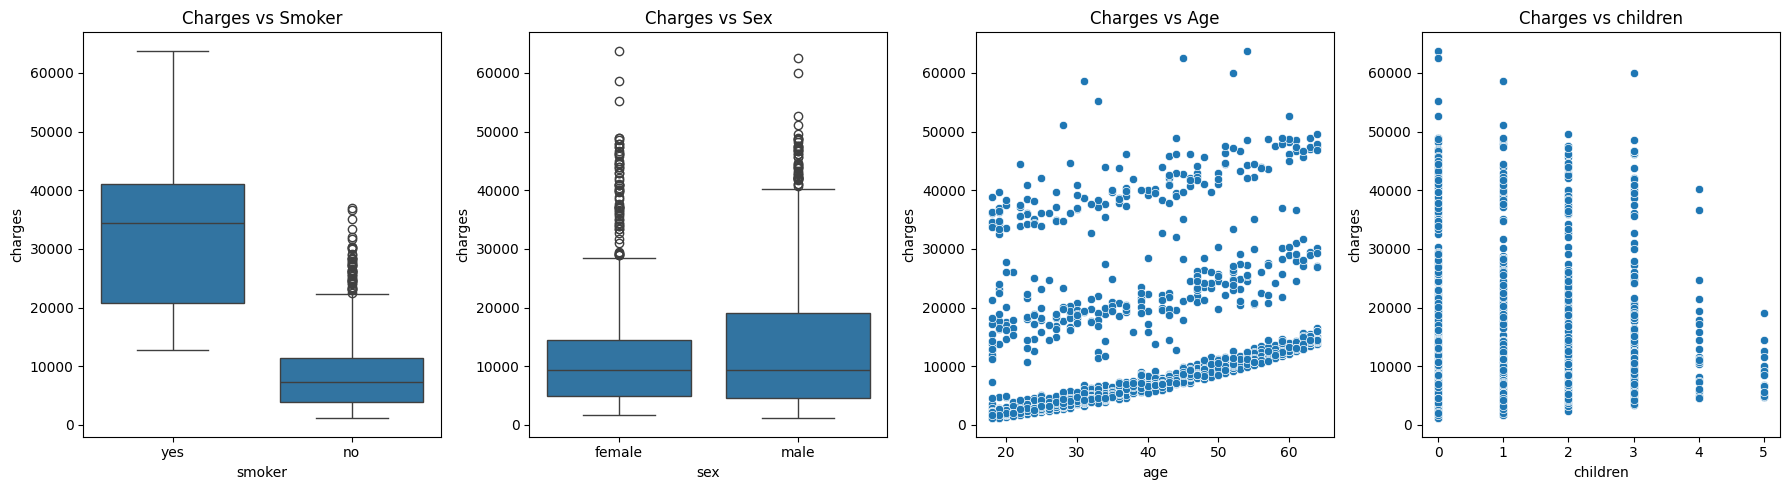

In [11]:
fig, axis = plt.subplots(1, 4, figsize=(18,5))

sns.boxplot(data=df, x="smoker", y="charges", ax=axis[0])
axis[0].set_title("Charges vs Smoker")

sns.boxplot(data=df, x="sex", y="charges", ax=axis[1])
axis[1].set_title("Charges vs Sex")

sns.scatterplot(data=df, x="age", y="charges", ax=axis[2])
axis[2].set_title("Charges vs Age")

sns.scatterplot(data=df, x="children", y="charges", ax=axis[3])
axis[3].set_title("Charges vs children")

plt.tight_layout()
plt.show()

el habito de fumar influye en la prima del seguro ya que tienen a aumentar el coste. El sexo no representa una variable que influya en los costes de la prima , a diferencia de la edad que si hay una clara relacion positiva ya que a medida que aumenta la edad los precios de la prima aumentan. 

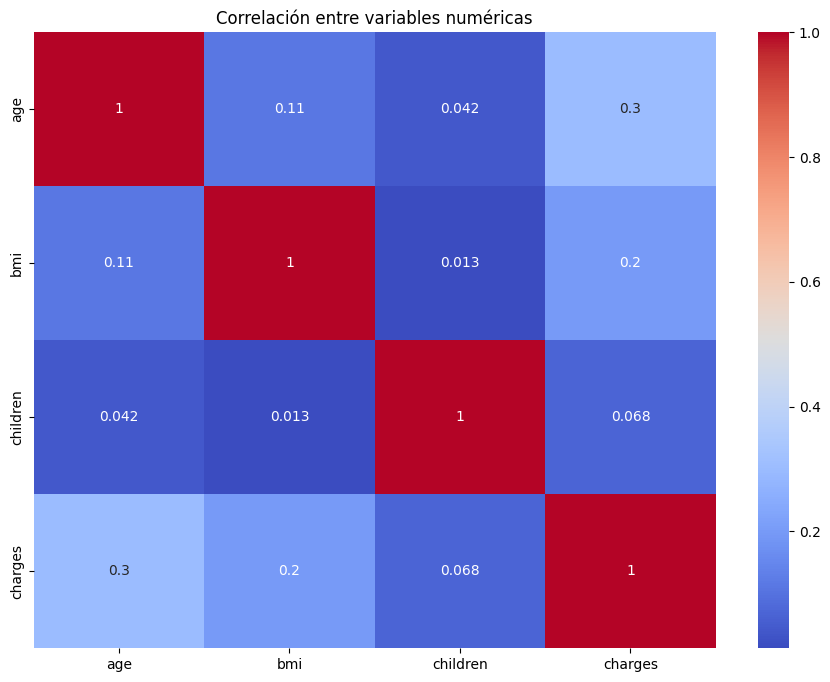

In [12]:
plt.figure(figsize=(11, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()

Existe una correlación positiva con la edad y el indice de masa corporal lo que se define a que a medida que la edad y el indice de masa comporal aumentan, el costo del seguro medico también aumenta 

In [13]:
data_dummies= pd.get_dummies(df, drop_first=True)
data_dummies

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


Transformamos las variables categoricas en variables binarias 

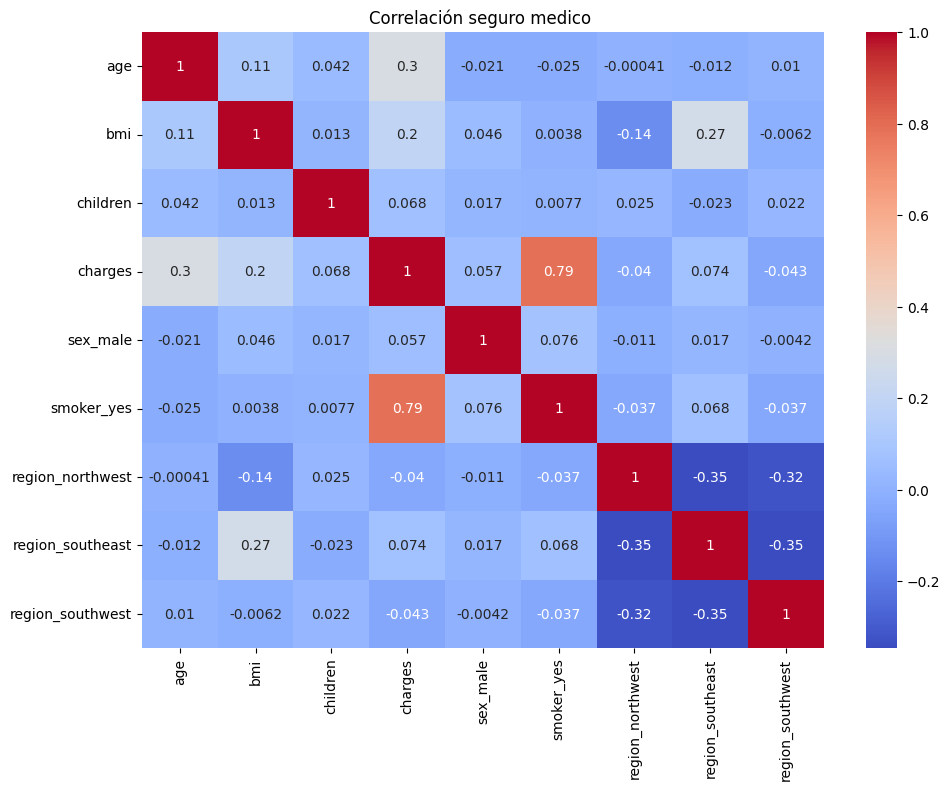

In [14]:
plt.figure(figsize=(11, 8))
corr = data_dummies.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlación seguro medico ')
plt.show()

Podemos observar que los que fuman, tienen una fuerte relacion positiva con el precio de la prima, la edad y el índice de masa corporal muestran una relación positiva moderada

In [15]:
data_dummies.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


pasos:
1 - SPLIT
2. ENCODED
3 - ESCALADO

# Split


In [17]:
X = df.drop("charges", axis= 1)
y = df["charges"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,age,sex,bmi,children,smoker,region
560,46,female,19.950,2,no,northwest
1285,47,female,24.320,0,no,northeast
1142,52,female,24.860,0,no,southeast
969,39,female,34.320,5,no,southeast
486,54,female,21.470,3,no,northwest
...,...,...,...,...,...,...
1095,18,female,31.350,4,no,northeast
1130,39,female,23.870,5,no,southeast
1294,58,male,25.175,0,no,northeast
860,37,female,47.600,2,yes,southwest


In [19]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_train_encoded

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,46,19.950,2,False,False,True,False,False
1285,47,24.320,0,False,False,False,False,False
1142,52,24.860,0,False,False,False,True,False
969,39,34.320,5,False,False,False,True,False
486,54,21.470,3,False,False,True,False,False
...,...,...,...,...,...,...,...,...
1095,18,31.350,4,False,False,False,False,False
1130,39,23.870,5,False,False,False,True,False
1294,58,25.175,0,True,False,False,False,False
860,37,47.600,2,False,True,False,False,True


In [20]:
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
764,45,25.175,2,False,False,False,False,False
887,36,30.020,0,False,False,True,False,False
890,64,26.885,0,False,True,True,False,False
1293,46,25.745,3,True,False,True,False,False
259,19,31.920,0,True,True,True,False,False
...,...,...,...,...,...,...,...,...
109,63,35.090,0,True,True,False,True,False
575,58,27.170,0,False,False,True,False,False
535,38,28.025,1,True,False,False,False,False
543,54,47.410,0,False,True,False,True,False


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)   # fit solo en train
X_test_scaled = scaler.transform(X_test_encoded)          # transform en test

# Modelo de regresión lineal 


In [22]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred = model.predict(X_test_scaled)
y_pred

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084137, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673493, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303302, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

In [24]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MAE: 4181.1945
R²: 0.7836


Tenemos un error de 4181.1945 y un R2 de 78% están explicados por el modelo

In [25]:
# ============================================
# OPTIMIZACIÓN REAL: Ridge con GridSearchCV
# ============================================

# Definir rango de alphas (regularización)
alphas = np.logspace(-3, 3, 50)  # De 0.001 a 1000

# Ridge
ridge = Ridge()
grid_ridge = GridSearchCV(
    ridge, 
    {'alpha': alphas}, 
    cv=5, 
    scoring='r2'
)
grid_ridge.fit(X_train_scaled, y_train)

print(f"Ridge - Mejor alpha: {grid_ridge.best_params_['alpha']:.4f}")
print(f"Ridge - Mejor R² (CV): {grid_ridge.best_score_:.4f}")

# Evaluar en test
y_pred_ridge = grid_ridge.predict(X_test_scaled)
print(f"Ridge - R² Test: {r2_score(y_test, y_pred_ridge):.4f}")

Ridge - Mejor alpha: 8.2864
Ridge - Mejor R² (CV): 0.7332
Ridge - R² Test: 0.7831


In [26]:
# ============================================
# OPTIMIZACIÓN REAL: Lasso con GridSearchCV
# ============================================
lasso = Lasso(max_iter=10000)
grid_lasso = GridSearchCV(
    lasso, 
    {'alpha': alphas}, 
    cv=5, 
    scoring='r2'
)
grid_lasso.fit(X_train_scaled, y_train)

print(f"\nLasso - Mejor alpha: {grid_lasso.best_params_['alpha']:.4f}")
print(f"Lasso - Mejor R² (CV): {grid_lasso.best_score_:.4f}")

y_pred_lasso = grid_lasso.predict(X_test_scaled)
print(f"Lasso - R² Test: {r2_score(y_test, y_pred_lasso):.4f}")


Lasso - Mejor alpha: 138.9495
Lasso - Mejor R² (CV): 0.7340
Lasso - R² Test: 0.7799


In [27]:
# REGRESIÓN LINEAL
r2_rl = r2_score(y_test, y_pred)
mae_rl = mean_absolute_error(y_test, y_pred)
rmse_rl = np.sqrt(mean_squared_error(y_test, y_pred))

# MODELO RIDGE
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# MODELO LASSO
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

In [28]:
comparacion = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Ridge", "Lasso"],
    "R2": [r2_rl, r2_ridge, r2_lasso],
    "MAE": [mae_rl, mae_ridge, mae_lasso],
    "RMSE": [rmse_rl, rmse_ridge, rmse_lasso]
})

comparacion

,Modelo,R2,MAE,RMSE
0,Regresión Lineal,0.783593,4181.194474,5796.284659
1,Ridge,0.783127,4194.819058,5802.527042
2,Lasso,0.779917,4214.459767,5845.299893


# Conlusión 

Vemos que con el modelo original explica un 78% esto quiere decir que el modelo lineal explica un 78% de relacion lineal con las variables que tenemos y observamos que el MAE en promedio se desvia un 4181.19. Al intentar mejorar el modelo utilizamos Ridge y Lasso pero esto no mejoro las metricas por lo que nuestro modelo original es el correcto. 

Cabe destacar que al dataframe no se le elimino ninguna columna, pienso que todas son relevantes para el analisis, en caso de que eliminemos alguna seria la de Children ya que observando la matriz de correlacion su valor es muy cercano al 0 por lo que no existiria una relacion lineal entre ambas variables. 

# Guardamos datos 

In [29]:
X_train.to_csv("../data/processed/X_train_medical.csv", index=False)
X_test.to_csv("../data/processed/X_test_medical.csv", index=False)

y_train.to_csv("../data/processed/y_train_medical.csv", index=False)
y_test.to_csv("../data/processed/y_test_medical.csv", index=False)